## Diagrama de Fase en R2

Sistema lineal dado por:

$$F(x,y) = (-y, -x)$$

$$\dot{\mathbf{x}} = F(\mathbf{x})$$

$$\begin{pmatrix} \dot{x} \\ \dot{y} \end{pmatrix} = F(x,y) = \begin{pmatrix} -y \\ -x \end{pmatrix}$$

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint
import pylab as pl

$$\begin{pmatrix} \dot{x} \\ \dot{y} \end{pmatrix} = \begin{pmatrix} 0 & -1 \\ -1 & 0 \end{pmatrix} \begin{pmatrix} x \\ y \end{pmatrix}$$

In [3]:
a,b,c,d = 0, -1, -1, 0

x[0] = x<br>
x[1] = y<br>
La función dx_dt tiene dos componentes, seria el vector escrito en forma horizontal.<br>

x' = a*x[0] + b*x[1] === x' = ax + by<br>
y' = c*x[0] + d*x[1] === y' = cx + dy

In [4]:
def dx_dt(x,t):
    return [a*x[0] + b*x[1], c*x[0] + d*x[1]]

Tiempo para adelante y para atras.<br>
Cuando integro tengo que hacerlo en ambas direcciones

In [5]:
t_f = np.linspace(0,4,100)
t_b = np.linspace(0,-4,100)

Grafico 5 trayectorias desde -10 a 10. El 5 indica que me dan 5 puntos entre -10 y 10

In [6]:
#condiicones iniciales
ic = np.linspace(-10,10,5)

In [7]:
ic

array([-10.,  -5.,   0.,   5.,  10.])

Para campo vectorial:

In [8]:
X,Y = np.mgrid[-10:10:20j, -10:10:20j]
u = a*X + b*Y
v = c*X + d*Y

Integro para obtener las trayectorias 5*5 = 25 trayectorias que grafico.Integrando obtengo x(t) e y(t) aproximado entonces con los tiempos de t_f y t_i se el recorrido en +-4 en 100 puntos

-10.0 -10.0
-10.0 -5.0
-10.0 0.0
-10.0 5.0
-10.0 10.0
-5.0 -10.0
-5.0 -5.0
-5.0 0.0
-5.0 5.0
-5.0 10.0
0.0 -10.0
0.0 -5.0
0.0 0.0
0.0 5.0
0.0 10.0
5.0 -10.0
5.0 -5.0
5.0 0.0
5.0 5.0
5.0 10.0
10.0 -10.0
10.0 -5.0
10.0 0.0
10.0 5.0
10.0 10.0


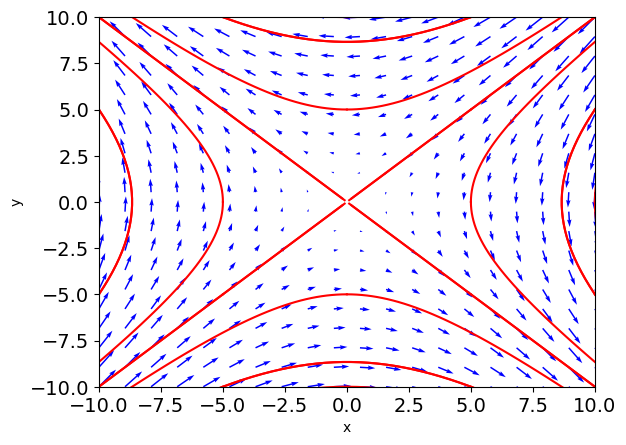

In [9]:
for r in ic:
    for s in ic:
        print(r,s)
        x0 = [r,s]
        xs_f = odeint(dx_dt,x0,t_f)
        xs_b = odeint(dx_dt,x0,t_b)
        plt.plot(xs_f[:,0],xs_f[:,1], 'r-')
        plt.plot(xs_b[:,0],xs_b[:,1], 'r-')

plt.xlabel('x')
plt.ylabel('y')
plt.tick_params(labelsize=14)
plt.xlim(-10,10)
plt.ylim(-10,10)
plt.quiver(X,Y,u,v, color='blue')

# Grafico interactivo para cambiar cantidad de trayectorias

In [10]:
from ipywidgets import interact, IntSlider, FloatSlider
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import numpy as np

def plot_phase(n_traj=5, t_max=4.0):
    # campo vectorial
    X, Y = np.mgrid[-10:10:20j, -10:10:20j]
    u = a*X + b*Y
    v = c*X + d*Y

    # condiciones iniciales
    ic = np.linspace(-10, 10, n_traj)

    t_f = np.linspace(0,  t_max, 300)
    t_b = np.linspace(0, -t_max, 300)

    fig, ax = plt.subplots(figsize=(6,6))

    for r in ic:
        for s in ic:
            x0 = [r, s]
            xs_f = odeint(dx_dt, x0, t_f)
            xs_b = odeint(dx_dt, x0, t_b)
            ax.plot(xs_f[:,0], xs_f[:,1], 'r-', lw=0.8)
            ax.plot(xs_b[:,0], xs_b[:,1], 'r-', lw=0.8)

    ax.quiver(X, Y, u, v, color='blue', alpha=0.5)
    ax.set_xlim(-10, 10)
    ax.set_ylim(-10, 10)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'Diagrama de fase  |  traj={n_traj}x{n_traj}, t_max={t_max}')
    ax.tick_params(labelsize=12)
    plt.tight_layout()
    plt.show()

interact(
    plot_phase,
    n_traj=IntSlider(min=2, max=10, step=1, value=5, description='cant traj'),
    t_max=FloatSlider(min=0.1, max=5.0, step=0.5, value=4.0, description='t_max')
)

interactive(children=(IntSlider(value=5, description='cant traj', max=10, min=2), FloatSlider(value=4.0, descr…

<function __main__.plot_phase(n_traj=5, t_max=4.0)>